# Librosa trial

[Librosa tutorial](https://github.com/librosa/tutorial)

Librosa requires a few additional packages to load audio data encoded in various formats (e.g., mp3, ogg, flac, m4a). The two main libraries used by librosa are ffmpeg and gstreamer. Both are optional, but you must install at least one package. Audio codec libraries are packaged differently on different platforms.

```bash
sudo apt install libcairo2-dev
sudo apt install libgirepository1.0-dev
sudo apt install ffmpeg
poetry add pygobject
```


In [1]:
import librosa
import librosa.display
import IPython
import numpy as np
import matplotlib.pyplot as plt

SOUND_FOLDER = '../data/sound/grasshopper-sound-4'


## Basic librosa function tests

In [2]:
a = np.arange(1, 10 ,1)
print(f'a: {a}')

a1 = 20 * np.log10(a)
print(f'a1: {a1}')

a2 = librosa.amplitude_to_db(a)
print(f'a2: {a2}')

a: [1 2 3 4 5 6 7 8 9]
a1: [ 0.          6.02059991  9.54242509 12.04119983 13.97940009 15.56302501
 16.9019608  18.06179974 19.08485019]
a2: [ 0.          6.02059991  9.54242509 12.04119983 13.97940009 15.56302501
 16.9019608  18.06179974 19.08485019]


In [3]:

fn = f'{SOUND_FOLDER}/gh-4_mono_22050_denoised.wav'
y, sr = librosa.load(fn)
dura = librosa.get_duration(y=y, sr=sr)
print(f'data shape: {y.shape}, data:\n{y[:20]}')
print(f'sample rate: {sr}')
print(f'duration: {dura}')


data shape: (228217,), data:
[ 9.1552734e-05  9.1552734e-05 -9.1552734e-05 -1.5258789e-04
 -9.1552734e-05  9.1552734e-05  1.2207031e-04  3.0517578e-05
 -1.5258789e-04 -1.2207031e-04  0.0000000e+00  1.2207031e-04
  9.1552734e-05 -6.1035156e-05 -1.8310547e-04 -6.1035156e-05
  6.1035156e-05  1.2207031e-04  0.0000000e+00 -1.2207031e-04]
sample rate: 22050
duration: 10.349977324263039


In [4]:

IPython.display.display(IPython.display.Audio(data=y, rate=sr))
# IPython.display.Audio(data=y, rate=sr)
print('hello')

hello


## Split into sub sound track

In [18]:
fn2 = f'../data/sound/count_to_10_mono_22050.wav'

y2, sr2 = librosa.load(fn2)
dura2 = librosa.get_duration(y=y2, sr=sr2)
print(f'data shape: {y2.shape}, data:\n{y2[:20]}')
print(f'sample rate: {sr2}')
print(f'duration: {dura2}')

IPython.display.display(IPython.display.Audio(data=y2, rate=sr2))

data shape: (241316,), data:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
sample rate: 22050
duration: 10.94403628117914


In [20]:

slices = librosa.stream(fn2, block_length=1, frame_length=sr2*3,
    hop_length=int(sr2*2), mono=True, fill_value=0)
for i in slices:
    IPython.display.display(IPython.display.Audio(data=i, rate=sr))


## identify silence

In [34]:
intervals = librosa.effects.split(y, top_db=20)
print(f'intervals shape: {intervals.shape}, content:\n{intervals}')

intervals shape: (11, 2), content:
[[  2048  11776]
 [ 33792  38400]
 [ 67072  71680]
 [ 78848  82944]
 [ 99840 103936]
 [131584 135680]
 [141824 145920]
 [164864 167936]
 [176640 181760]
 [196608 198656]
 [216576 224768]]


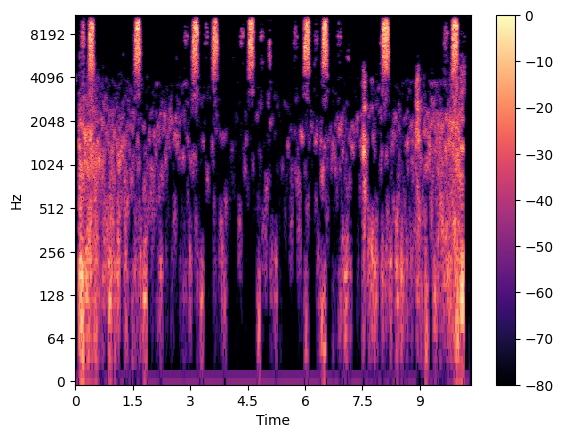

In [12]:
# And compute the spectrogram magnitude and phase
S_full, phase = librosa.magphase(librosa.stft(y))


###################
# Plot the spectrum
fig, ax = plt.subplots()
img = librosa.display.specshow(librosa.amplitude_to_db(S_full, ref=np.max),
                               y_axis='log', x_axis='time', sr=sr, ax=ax)
fig.colorbar(img, ax=ax);

rms shape: (446,)
times len: 446, times:
[0.         0.02321995 0.04643991 0.06965986 0.09287982 0.11609977
 0.13931973 0.16253968 0.18575964 0.20897959]
[10.12390023 10.14712018 10.17034014 10.19356009 10.21678005 10.24
 10.26321995 10.28643991 10.30965986 10.33287982]


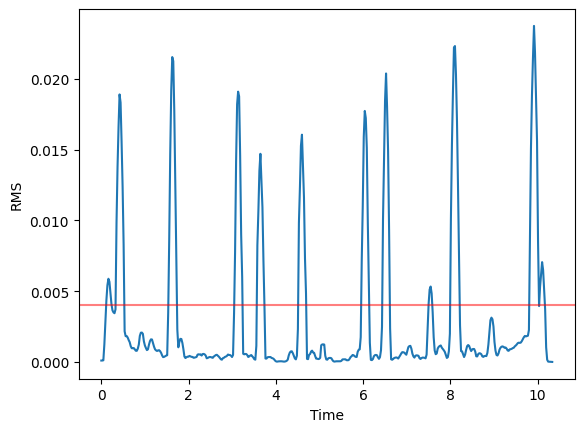

In [22]:
# As a first step, we can plot the root-mean-square (RMS) curve
rms = librosa.feature.rms(y=y)[0]
print(f'rms shape: {rms.shape}')
times = librosa.frames_to_time(np.arange(len(rms)))
print(f'times len: {len(times)}, times:\n{times[:10]}\n{times[-10:]}')

fig, ax = plt.subplots()
ax.plot(times, rms)
cut_line = 0.004
ax.axhline(cut_line, color='r', alpha=0.5)
ax.set(xlabel='Time', ylabel='RMS');


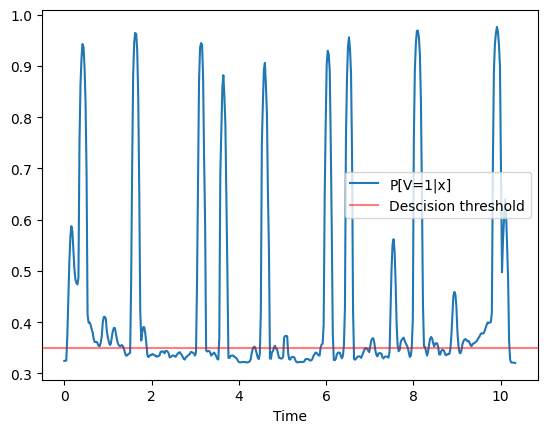

In [24]:
r_normalized = (rms - cut_line) / np.std(rms)
p = np.exp(r_normalized) / (1 + np.exp(r_normalized))

fig, ax = plt.subplots()
ax.plot(times, p, label='P[V=1|x]')
ax.axhline(0.35, color='r', alpha=0.5, label='Descision threshold')
ax.set(xlabel='Time')
ax.legend()

<Figure size 1200x600 with 0 Axes>

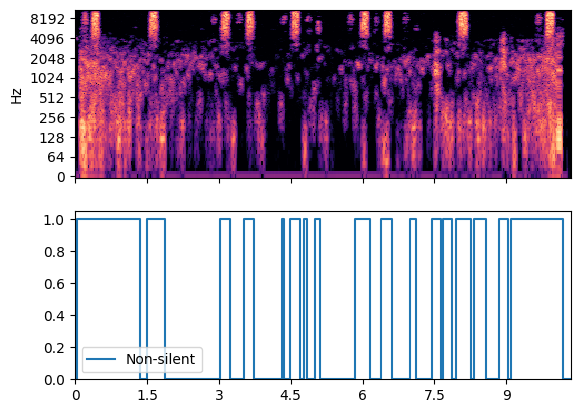

In [25]:
plt.figure(figsize=(12, 6))
fig, ax = plt.subplots(nrows=2, sharex=True)
librosa.display.specshow(librosa.amplitude_to_db(S_full, ref=np.max),
                         y_axis='log', x_axis='time', sr=sr, ax=ax[0])
ax[0].label_outer()
ax[1].step(times, p>=0.35, label='Non-silent')
ax[1].set(ylim=[0, 1.05])
ax[1].legend()

In [5]:
# 3. Run the default beat tracker
tempo, beat_frames = librosa.beat.beat_track(y=y, sr=sr)

print('Estimated tempo: {:.2f} beats per minute'.format(tempo))

# 4. Convert the frame indices of beat events into timestamps
beat_times = librosa.frames_to_time(beat_frames, sr=sr)
print(beat_frames)

Estimated tempo: 123.05 beats per minute
[  5  27  48  69  90 112 134 156 176 197 218 239 259 279 301 324 345 365]


In [6]:
# 1. Get the file path to an included audio example
filename = librosa.example('nutcracker')


# 2. Load the audio as a waveform `y`
#    Store the sampling rate as `sr`
y, sr = librosa.load(filename)
IPython.display.Audio(data=y, rate=sr)

In [7]:

# 3. Run the default beat tracker
tempo, beat_frames = librosa.beat.beat_track(y=y, sr=sr)

print('Estimated tempo: {:.2f} beats per minute'.format(tempo))

# 4. Convert the frame indices of beat events into timestamps
beat_times = librosa.frames_to_time(beat_frames, sr=sr)

Estimated tempo: 107.67 beats per minute


In [9]:
librosa.util.list_examples()

AVAILABLE EXAMPLES
--------------------------------------------------------------------
brahms    	Brahms - Hungarian Dance #5
choice    	Admiral Bob - Choice (drum+bass)
fishin    	Karissa Hobbs - Let's Go Fishin'
humpback  	Glacier Bay 60-second clip humpback whale song November 2020
libri1    	Ashiel Mystery - A Detective Story, chapter 2, narrated by Garth Comira
libri2    	The Age of Chivalry / Chapter 18: Perceval / Read by Anders Lankford
libri3    	Sense and Sensibility / Chapter 18 / Jane Austen / Read by Heather Barnett
nutcracker	Tchaikovsky - Dance of the Sugar Plum Fairy
pistachio 	The Piano Lady - Pistachio Ice Cream Ragtime
robin     	Bird Whistling, Robin, Single, 13.wav / InspectorJ
sweetwaltz	Setuniman - Sweet Waltz
trumpet   	Mihai Sorohan - Trumpet loop
vibeace   	Kevin MacLeod - Vibe Ace
